# Self-Organizing Maps (SOMs) Notebook - Alaska Cyclones
## Plot March and September Alaskan regional SIC for 1950-1960, 1980-1990, and 2010-2020

**Notebook by Alice DuVivier - June 2026**

In [1]:
import pandas as pd
import xarray as xr
import cftime
import numpy as np
import pandas as pd
from itertools import product
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from datetime import timedelta
from itertools import product
import cmocean
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mtick

## Load Model data
- regional, monthly data by decade

### Get grid data

In [2]:
# load grid files for plotting

dir_grid = '/glade/u/home/duvivier/masks/'
file_in = 'POP_tx0.1v3_grid.nc'
ds_grid = xr.open_mfdataset(dir_grid+file_in, decode_times=False)    

# clip global data to match other files - do in two steps because that's how I originally clipped data
# Step 1: clip to full Arctic Region
ds_grid_sub = ds_grid.isel(nlat=slice(1750,2400))
# Step 2: clip Arctic Region to Pacific sector only
ds_grid_sub = ds_grid_sub.isel(nlon=slice(2500,3250))

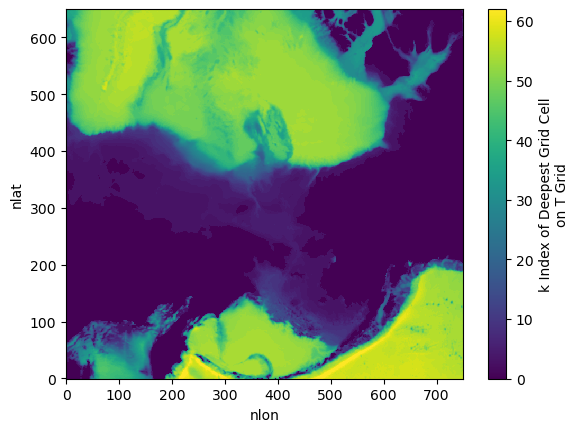

In [3]:
ds_grid_sub.KMT.plot()

In [4]:
# grab lat and lon data
cesm_lat2d = ds_grid_sub.TLAT
cesm_lon2d = ds_grid_sub.TLONG

### Get Model SIC data
- Model monthly data by decade (1920-29, 1950-59, 1980-89, 2010-2019) - has been preprocessed

In [5]:
# set path where the som finalist files are
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/SOM_alaska_cyclones/mesaclip_validation/'
fin = 'mesaclip_sic_march_steptember_alaska_region.nc'

ds = xr.open_dataset(dir_in+fin)

In [6]:
ds

<xarray.Dataset> Size: 16MB
Dimensions:       (nj: 650, ni: 750)
Dimensions without coordinates: nj, ni
Data variables:
    sic_mar_1920  (nj, ni) float32 2MB ...
    sic_mar_1950  (nj, ni) float32 2MB ...
    sic_mar_1980  (nj, ni) float32 2MB ...
    sic_mar_2010  (nj, ni) float32 2MB ...
    sic_sep_1920  (nj, ni) float32 2MB ...
    sic_sep_1950  (nj, ni) float32 2MB ...
    sic_sep_1980  (nj, ni) float32 2MB ...
    sic_sep_2010  (nj, ni) float32 2MB ...
Attributes:
    author:          Alice DuVivier
    date_processed:  2026-06-25
    contents:        MESACLIP Arctic sea ice for validation

In [7]:
# load data
cesm_mar_1920 = ds.sic_mar_1920
cesm_mar_1950 = ds.sic_mar_1950
cesm_mar_1980 = ds.sic_mar_1980
cesm_mar_2010 = ds.sic_mar_2010

cesm_sep_1920 = ds.sic_sep_1920
cesm_sep_1950 = ds.sic_sep_1950
cesm_sep_1980 = ds.sic_sep_1980
cesm_sep_2010 = ds.sic_sep_2010

## Load CDR satellite SIC data
- daily NH data on 25km x 25km grid

### Get grid data

In [8]:
# load grid files for plotting

dir_grid = '/glade/campaign/cesm/development/pcwg/ssmi/'
file_in = 'grid_nh.nc'
ds_grid = xr.open_mfdataset(dir_grid+file_in, decode_times=False)    

In [9]:
ds_grid

<xarray.Dataset> Size: 2MB
Dimensions:     (ygrid: 448, xgrid: 304)
Coordinates:
  * xgrid       (xgrid) float32 1kB -3.838e+06 -3.812e+06 ... 3.738e+06
  * ygrid       (ygrid) float32 2kB 5.838e+06 5.812e+06 ... -5.338e+06
Data variables:
    latitude    (ygrid, xgrid) float64 1MB dask.array<chunksize=(448, 304), meta=np.ndarray>
    longitude   (ygrid, xgrid) float64 1MB dask.array<chunksize=(448, 304), meta=np.ndarray>
    projection  |S182 182B ...
Attributes: (12/43)
    Conventions:               CF-1.6
    title:                     NOAA/NSIDC Climate Data Record of Passive Micr...
    references:                Comiso, J. C., and F. Nishio. 2008. Trends in ...
    cdr_program:               NOAA Climate Data Record Program
    cdr_variable:              seaice_conc_cdr
    software_version_id:       svn+ssh://newice.colorado.edu/SubversionReposi...
    ...                        ...
    sensor:                    SMMR > Scanning Multichannel Microwave Radiometer
    date_created:              2013-05-22T19:11:43Z
    time_coverage_start:       1979-01-02T00:00:00Z
    time_coverage_end:         1979-01-02T23:59:59Z
    comment:                   The variables seaice_conc_cdr, stdev_of_seaice...
    nco_openmp_thread_number:  1

In [10]:
# grab lat and lon data
cdr_lat2d = ds_grid.latitude
cdr_lon2d = ds_grid.longitude

### Get CDR SIC data
- Satellite monthly data by decade (1980-89, 2010-2019) - daily and then average to monthly

In [11]:
dir_in = '/glade/campaign/cesm/development/pcwg/ssmi/CDR/'
file_in = 'cdr_seaice_conc_daily_nh.cdr.noleap.19790101-20211231.nc'

ds_cdr = xr.open_dataset(dir_in + file_in)

In [12]:
# check time array
ds_cdr.time

<xarray.DataArray 'time' (time: 15695)> Size: 63kB
array([138061., 138062., 138063., ..., 153764., 153765., 153766.],
      dtype=float32)
Coordinates:
  * time     (time) float32 63kB 1.381e+05 1.381e+05 ... 1.538e+05 1.538e+05

In [13]:
# make array of the dates
#dates = pd.date_range(start="1979-01-01", end="2021-12-31", freq="D")
dates_noleap = xr.cftime_range(start="1979-01-01", end="2021-12-31", freq="D", calendar="noleap")
print(len(dates_noleap))

15695


/glade/derecho/scratch/duvivier/tmp/ipykernel_44454/1032269101.py:3: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  dates_noleap = xr.cftime_range(start="1979-01-01", end="2021-12-31", freq="D", calendar="noleap")


In [14]:
# reassign the polynya time array
ds_cdr['time'] = dates_noleap
ds_cdr['time'] = dates_noleap

In [15]:
ds_cdr.time

<xarray.DataArray 'time' (time: 15695)> Size: 126kB
array([cftime.DatetimeNoLeap(1979, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1979, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1979, 1, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2021, 12, 29, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 12, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 126kB 1979-01-01 00:00:00 ... 2021-12-31 00:00:00

In [16]:
# create monthly averages from the daily data
ds_cdr_monthly = ds_cdr.resample(time='ME').mean()

In [17]:
ds_cdr_monthly.time

<xarray.DataArray 'time' (time: 516)> Size: 4kB
array([cftime.DatetimeNoLeap(1979, 1, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1979, 2, 28, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1979, 3, 31, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2021, 10, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 11, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 4kB 1979-01-31 00:00:00 ... 2021-12-31 00:00:00

In [18]:
# save only variable of interest and divide by 100 to get on a 0-1 range
ds_cdr_monthly = ds_cdr_monthly.cdr_seaice_conc_daily

### Get data just for march and september

In [19]:
sic_cdr_mar = ds_cdr_monthly.sel(time=ds_cdr_monthly.time.dt.month == 3)
sic_cdr_sep = ds_cdr_monthly.sel(time=ds_cdr_monthly.time.dt.month == 9)

### Subset the Decades of interest
- 1980-1990, 2010-2020
- also calculate mean over all years

In [20]:
yrs_load_1980 = np.arange(1980,1990,1)
yrs_load_2010 = np.arange(2010,2020,1)

In [21]:
# get just these decades for each month *and* average
cdr_mar_1980 = sic_cdr_mar.isel(time=sic_cdr_mar.time.dt.year.isin([yrs_load_1980])).mean(dim=['time'])
cdr_mar_2010 = sic_cdr_mar.isel(time=sic_cdr_mar.time.dt.year.isin([yrs_load_2010])).mean(dim=['time'])

cdr_sep_1980 = sic_cdr_sep.isel(time=sic_cdr_sep.time.dt.year.isin([yrs_load_1980])).mean(dim=['time'])
cdr_sep_2010 = sic_cdr_sep.isel(time=sic_cdr_sep.time.dt.year.isin([yrs_load_2010])).mean(dim=['time'])

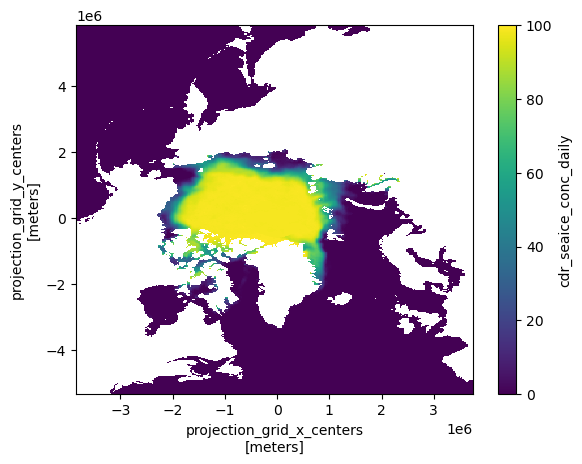

In [22]:
cdr_sep_1980.plot()

## Plot Maps by decade and month to compare

In [23]:
# set output directory
dir_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/SOM_alaska_cyclones/analysis_v2/'

In [24]:
# set lat/lon bounds
lat_max = 80 #72 #75
lat_min = 52 #52 #50
lon_max = 205 #218 #220
lon_min = 175 #182 #170
lon_avg = 191.625

In [25]:
## set colors and levels for sst
cmap_in = cmocean.cm.ice
vmin_in = 0
vmax_in = 100
levels_in = np.arange(0,105,5)
ticks_in = [0,10,20,30,40,50,60,70,80,90,100]
units_in = '%'
var_in = 'SIC'

In [39]:
# set ice edge line for overlay contour plot
#levels_diff = np.arange(15,20,5)
levels_diff = [15,100]

### Create SIC mean plots

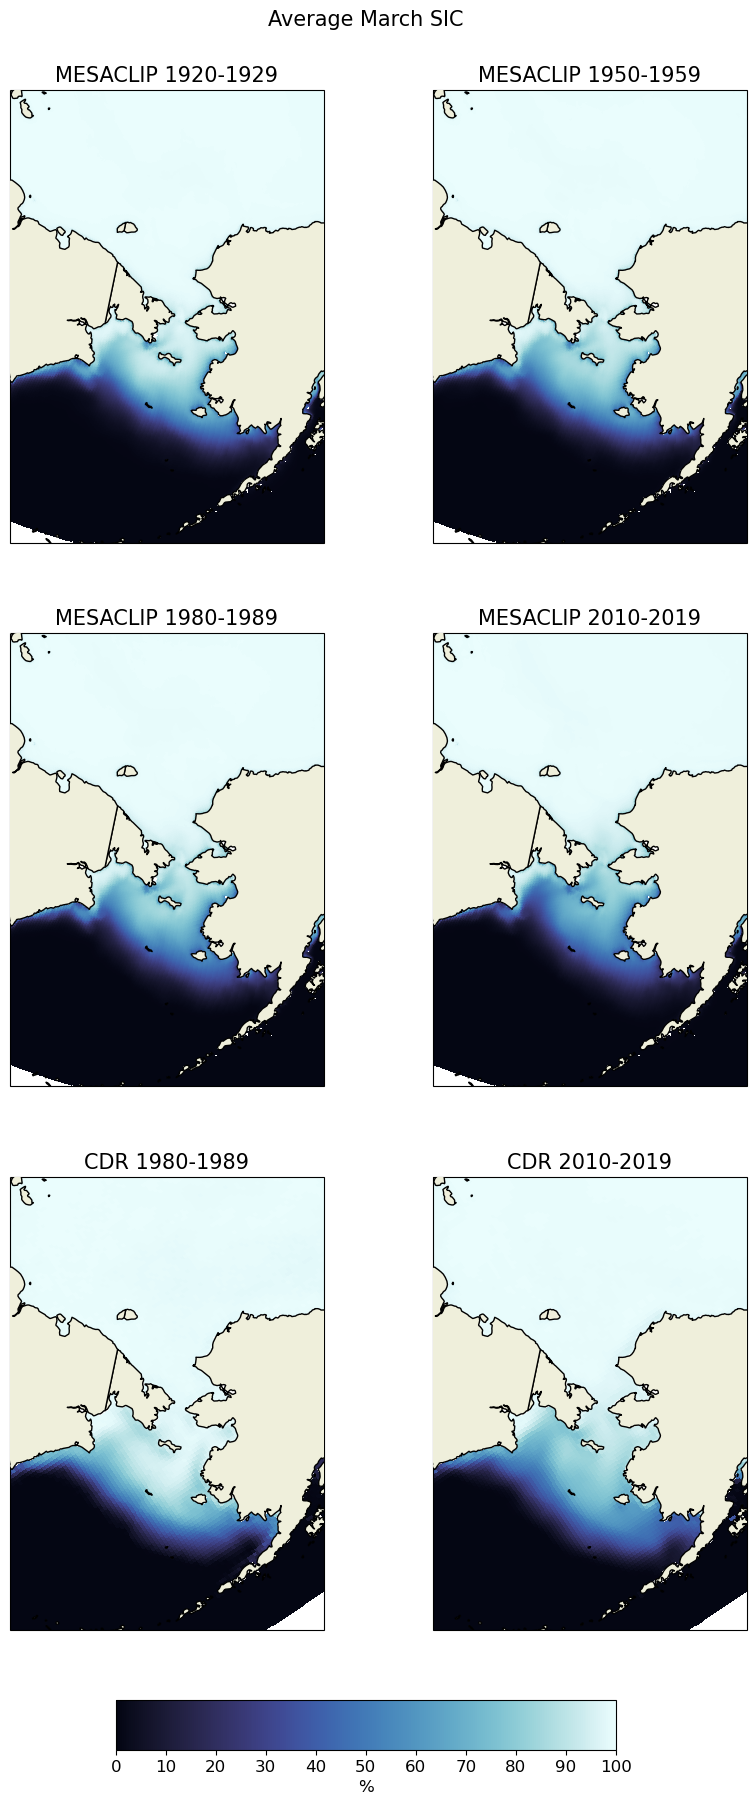

In [54]:
# march

#### 
# create figure
fig = plt.figure(figsize=(10,20))
fout = 'mesaclip_alaska_march_spatial_validation'

# Make subplots - note it's nrow x ncol x index (starting upper left)
### MESA - 1920
ax = fig.add_subplot(3,2,1, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cesm_lon2d, cesm_lat2d, cesm_mar_1920, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('MESACLIP 1920-1929',fontsize=15)

### MESA - 1950
ax = fig.add_subplot(3,2,2, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cesm_lon2d, cesm_lat2d, cesm_mar_1950, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('MESACLIP 1950-1959',fontsize=15)

### MESA - 1980
ax = fig.add_subplot(3,2,3, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cesm_lon2d, cesm_lat2d, cesm_mar_1980, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('MESACLIP 1980-1989',fontsize=15)

### MESA - 2010
ax = fig.add_subplot(3,2,4, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cesm_lon2d, cesm_lat2d, cesm_mar_2010, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('MESACLIP 2010-2019',fontsize=15)

### CDR - 1980
ax = fig.add_subplot(3,2,5, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cdr_lon2d, cdr_lat2d, cdr_mar_1980, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('CDR 1980-1989',fontsize=15)

### CDR - 2010
ax = fig.add_subplot(3,2,6, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cdr_lon2d, cdr_lat2d, cdr_mar_2010, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('CDR 2010-2019',fontsize=15)


# Finalize figure and save
#add title
fig.suptitle('Average March SIC',fontsize=15, y=0.92)

# colorbar stuff
cbar_ax = fig.add_axes([0.25,0.05,0.5,0.025]) 
cbar = fig.colorbar(cs, cax=cbar_ax, ticks=ticks_in[:],orientation='horizontal')
cbar.ax.set_xticklabels(list(ticks_in))
cbar.ax.tick_params(labelsize=12)
cbar.set_label(units_in, fontsize=12)

# save figure
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)

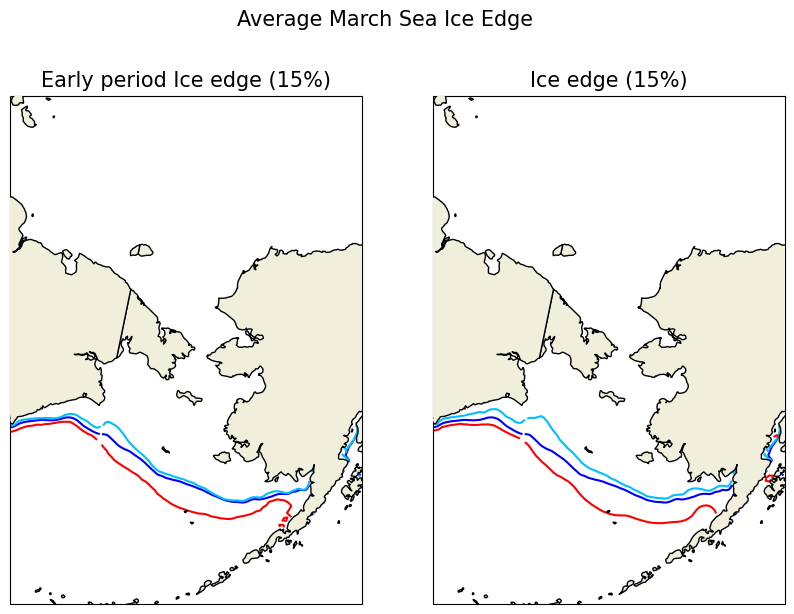

In [55]:
# march

#### 
# create figure
fig = plt.figure(figsize=(10,8))
fout = 'mesaclip_alaska_march_spatial_validation_ice_edges'

# Make subplots - note it's nrow x ncol x index (starting upper left)
### Early period
ax = fig.add_subplot(1,2,1, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
# ice edge contour lines - mask where longitude wraps around dateline
# MESACLIP - 1950s
data_masked = np.ma.masked_where(np.abs(np.diff(cesm_lon2d, axis=1)) > 180,cesm_mar_1950[:, :-1])
cs1 = ax.contour(cesm_lon2d[:, :-1], cesm_lat2d[:, :-1], data_masked, colors='blue',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())    
# MESACLIP - 1980s
data_masked = np.ma.masked_where(np.abs(np.diff(cesm_lon2d, axis=1)) > 180,cesm_mar_1980[:, :-1])
cs1 = ax.contour(cesm_lon2d[:, :-1], cesm_lat2d[:, :-1], data_masked, colors='deepskyblue',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())    
# CDR - 1980s
data_masked = np.ma.masked_where(np.abs(np.diff(cdr_lon2d, axis=1)) > 180,cdr_mar_1980[:, :-1])
cs2 = ax.contour(cdr_lon2d[:, :-1], cdr_lat2d[:, :-1], data_masked, colors='red',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('Early period Ice edge (15%)',fontsize=15)

### Later period
ax = fig.add_subplot(1,2,2, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
# ice edge contour lines - mask where longitude wraps around dateline
# MESACLIP - 1950s
data_masked = np.ma.masked_where(np.abs(np.diff(cesm_lon2d, axis=1)) > 180,cesm_mar_1950[:, :-1])
cs1 = ax.contour(cesm_lon2d[:, :-1], cesm_lat2d[:, :-1], data_masked, colors='blue',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())    
# MESACLIP - 2010s
data_masked = np.ma.masked_where(np.abs(np.diff(cesm_lon2d, axis=1)) > 180,cesm_mar_2010[:, :-1])
cs1 = ax.contour(cesm_lon2d[:, :-1], cesm_lat2d[:, :-1], data_masked, colors='deepskyblue',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())    
# CDR - 2010s
data_masked = np.ma.masked_where(np.abs(np.diff(cdr_lon2d, axis=1)) > 180,cdr_mar_2010[:, :-1])
cs2 = ax.contour(cdr_lon2d[:, :-1], cdr_lat2d[:, :-1], data_masked, colors='red',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('Ice edge (15%)',fontsize=15)

# Finalize figure and save
#add title
fig.suptitle('Average March Sea Ice Edge',fontsize=15, y=0.92)

# save figure
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)

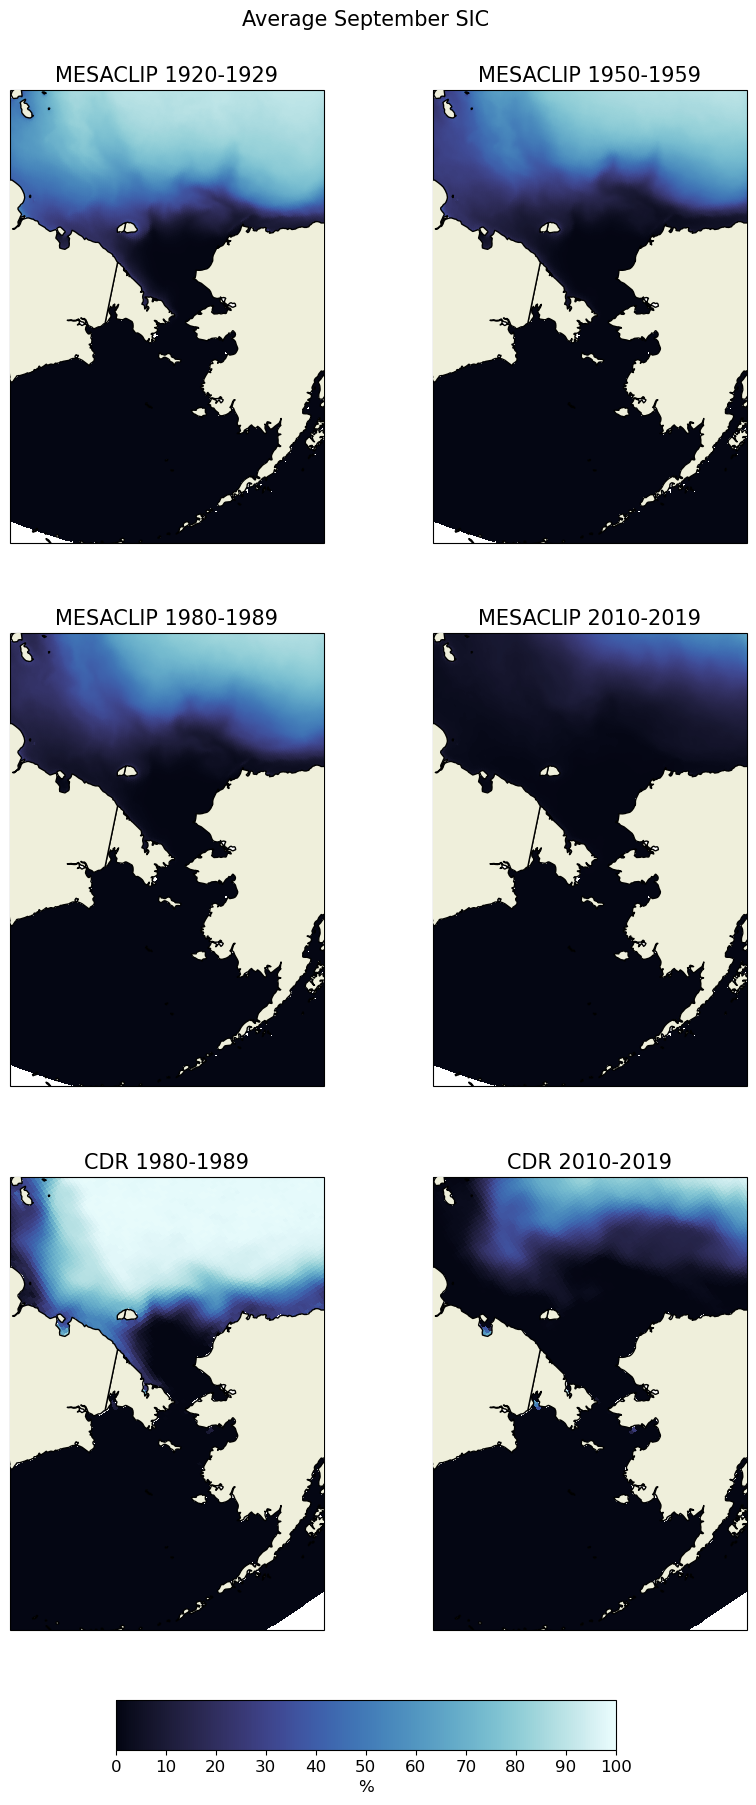

In [56]:
# september

#### 
# create figure
fig = plt.figure(figsize=(10,20))
fout = 'mesaclip_alaska_september_spatial_validation'

# Make subplots - note it's nrow x ncol x index (starting upper left)
### MESA - 1920
ax = fig.add_subplot(3,2,1, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cesm_lon2d, cesm_lat2d, cesm_sep_1920, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('MESACLIP 1920-1929',fontsize=15)

### MESA - 1950
ax = fig.add_subplot(3,2,2, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cesm_lon2d, cesm_lat2d, cesm_sep_1950, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('MESACLIP 1950-1959',fontsize=15)

### MESA - 1980
ax = fig.add_subplot(3,2,3, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cesm_lon2d, cesm_lat2d, cesm_sep_1980, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('MESACLIP 1980-1989',fontsize=15)

### MESA - 2010
ax = fig.add_subplot(3,2,4, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cesm_lon2d, cesm_lat2d, cesm_sep_2010, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('MESACLIP 2010-2019',fontsize=15)

### CDR - 1980
ax = fig.add_subplot(3,2,5, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cdr_lon2d, cdr_lat2d, cdr_sep_1980, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('CDR 1980-1989',fontsize=15)

### CDR - 2010
ax = fig.add_subplot(3,2,6, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
cs = ax.pcolormesh(cdr_lon2d, cdr_lat2d, cdr_sep_2010, vmin=vmin_in, vmax=vmax_in, cmap=cmap_in, transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('CDR 2010-2019',fontsize=15)


# Finalize figure and save
#add title
fig.suptitle('Average September SIC',fontsize=15, y=0.92)

# colorbar stuff
cbar_ax = fig.add_axes([0.25,0.05,0.5,0.025]) 
cbar = fig.colorbar(cs, cax=cbar_ax, ticks=ticks_in[:],orientation='horizontal')
cbar.ax.set_xticklabels(list(ticks_in))
cbar.ax.tick_params(labelsize=12)
cbar.set_label(units_in, fontsize=12)

# save figure
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)

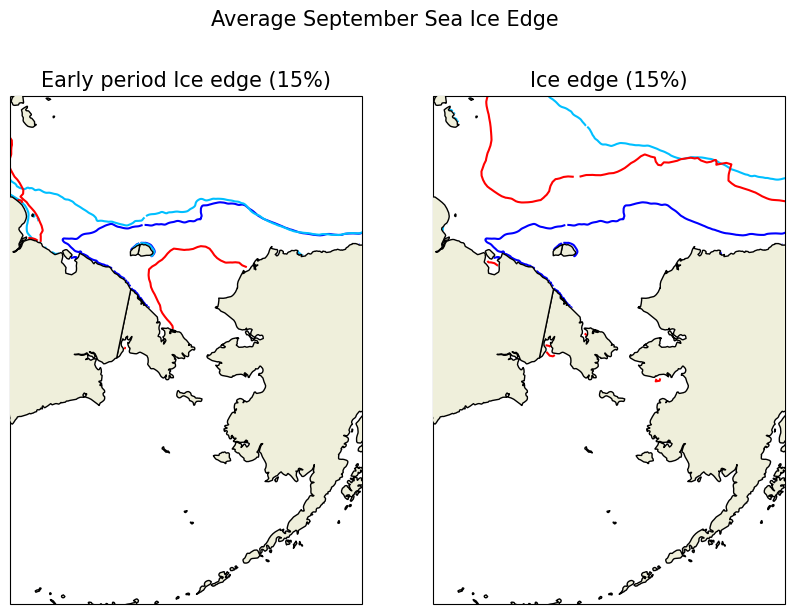

In [57]:
# september

#### 
# create figure
fig = plt.figure(figsize=(10,8))
fout = 'mesaclip_alaska_september_spatial_validation_ice_edges'

# Make subplots - note it's nrow x ncol x index (starting upper left)
### Early period
ax = fig.add_subplot(1,2,1, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
# ice edge contour lines - mask where longitude wraps around dateline
# MESACLIP - 1950s
data_masked = np.ma.masked_where(np.abs(np.diff(cesm_lon2d, axis=1)) > 180,cesm_sep_1950[:, :-1])
cs1 = ax.contour(cesm_lon2d[:, :-1], cesm_lat2d[:, :-1], data_masked, colors='blue',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())    
# MESACLIP - 1980s
data_masked = np.ma.masked_where(np.abs(np.diff(cesm_lon2d, axis=1)) > 180,cesm_sep_1980[:, :-1])
cs1 = ax.contour(cesm_lon2d[:, :-1], cesm_lat2d[:, :-1], data_masked, colors='deepskyblue',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())    
# CDR - 1980s
data_masked = np.ma.masked_where(np.abs(np.diff(cdr_lon2d, axis=1)) > 180,cdr_sep_1980[:, :-1])
cs2 = ax.contour(cdr_lon2d[:, :-1], cdr_lat2d[:, :-1], data_masked, colors='red',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('Early period Ice edge (15%)',fontsize=15)

### Later period
ax = fig.add_subplot(1,2,2, projection=ccrs.NorthPolarStereo(central_longitude=lon_avg))
# ice edge contour lines - mask where longitude wraps around dateline
# MESACLIP - 1950s
data_masked = np.ma.masked_where(np.abs(np.diff(cesm_lon2d, axis=1)) > 180,cesm_sep_1950[:, :-1])
cs1 = ax.contour(cesm_lon2d[:, :-1], cesm_lat2d[:, :-1], data_masked, colors='blue',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())    
# MESACLIP - 2010s
data_masked = np.ma.masked_where(np.abs(np.diff(cesm_lon2d, axis=1)) > 180,cesm_sep_2010[:, :-1])
cs1 = ax.contour(cesm_lon2d[:, :-1], cesm_lat2d[:, :-1], data_masked, colors='deepskyblue',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())    
# CDR - 2010s
data_masked = np.ma.masked_where(np.abs(np.diff(cdr_lon2d, axis=1)) > 180,cdr_sep_2010[:, :-1])
cs2 = ax.contour(cdr_lon2d[:, :-1], cdr_lat2d[:, :-1], data_masked, colors='red',linestyles='solid',levels=levels_diff,transform=ccrs.PlateCarree())
# add features
ax.set_extent([lon_min,lon_max,lat_min,lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
plt.title('Ice edge (15%)',fontsize=15)

# Finalize figure and save
#add title
fig.suptitle('Average September Sea Ice Edge',fontsize=15, y=0.92)

# save figure
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)